# ============================================================
# MDE-CS-03_PRINCIPLES OF STATISTICAL MODELLING
# FULL PROJECT NOTEBOOK
# Name: Subhankar Biswas
# Matriculation Number: 30008967
# Dataset: Wine Quality Dataset (winequality-red.csv)
# ============================================================

# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import (
    skew,
    kurtosis,
    norm,
    gamma,
    multivariate_normal
)

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression

import warnings
warnings.filterwarnings("ignore")

# ============================================================
# 2. LOAD DATASET
# ============================================================

# Download from:
# https://archive.ics.uci.edu/dataset/186/wine+quality


In [2]:
file_path = "winequality-red.csv"

df = pd.read_csv(file_path, sep=";")

print("===================================================")
print("DATASET INFORMATION")
print("===================================================")

print(df.head())
print("\nDataset Shape:", df.shape)

DATASET INFORMATION
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
1      9.8        5  


# ============================================================
# 3. MATHEMATICAL FORMALISM
# ============================================================

In [3]:
print("""
===================================================
MATHEMATICAL FORMALISM
===================================================

Universe:
Ω = {ω1, ω2, ..., ωN}

Random Vector:
X = (X1, X2, ..., Xd)

Features include:
- fixed acidity
- volatile acidity
- citric acid
- alcohol
- density
- etc.

Value Space:
S = S1 × S2 × ... × Sd
""")


MATHEMATICAL FORMALISM

Universe:
Ω = {ω1, ω2, ..., ωN}

Random Vector:
X = (X1, X2, ..., Xd)

Features include:
- fixed acidity
- volatile acidity
- citric acid
- alcohol
- density
- etc.

Value Space:
S = S1 × S2 × ... × Sd



# ============================================================
# 4. DATA CLEANING
# ============================================================

In [4]:
print("===================================================")
print("MISSING VALUES")
print("===================================================")

print(df.isnull().sum())

print("""
No missing values detected.
Dataset is already clean.
""")

MISSING VALUES
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

No missing values detected.
Dataset is already clean.



# ============================================================
# 5. RAW DATA VISUALIZATION
# ============================================================

In [5]:
print("===================================================")
print("RAW DATA DESCRIPTION")
print("===================================================")

print(df.describe())

RAW DATA DESCRIPTION
       fixed acidity  volatile acidity  citric acid  residual sugar  \
count    1599.000000       1599.000000  1599.000000     1599.000000   
mean        8.319637          0.527821     0.270976        2.538806   
std         1.741096          0.179060     0.194801        1.409928   
min         4.600000          0.120000     0.000000        0.900000   
25%         7.100000          0.390000     0.090000        1.900000   
50%         7.900000          0.520000     0.260000        2.200000   
75%         9.200000          0.640000     0.420000        2.600000   
max        15.900000          1.580000     1.000000       15.500000   

         chlorides  free sulfur dioxide  total sulfur dioxide      density  \
count  1599.000000          1599.000000           1599.000000  1599.000000   
mean      0.087467            15.874922             46.467792     0.996747   
std       0.047065            10.460157             32.895324     0.001887   
min       0.012000         

# ============================================================
# 6. DISTRIBUTION + MOMENTS
# ============================================================

In [6]:
print("""
===================================================
Distribution and Moments
===================================================
""")


Distribution and Moments



# ============================================================
# 7. SELECT FEATURE
# ============================================================

In [7]:
X = df["alcohol"]

print("Selected Feature: Alcohol")

Selected Feature: Alcohol


# ============================================================
# 8. DISCRETIZATION
# ============================================================

In [8]:
bin_width = 0.5

bins = np.arange(X.min(), X.max() + bin_width, bin_width)

print("Bins:")
print(bins)

Bins:
[ 8.4  8.9  9.4  9.9 10.4 10.9 11.4 11.9 12.4 12.9 13.4 13.9 14.4 14.9]


# ============================================================
# 9. HISTOGRAM
# ============================================================

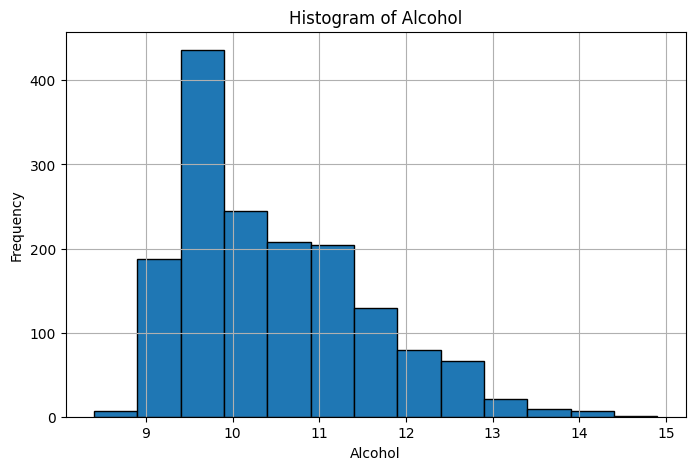

In [9]:
plt.figure(figsize=(8,5))

plt.hist(
    X,
    bins=bins,
    edgecolor='black'
)

plt.title("Histogram of Alcohol")
plt.xlabel("Alcohol")
plt.ylabel("Frequency")

plt.grid(True)

plt.show()

# ============================================================
# 10. PMF
# ============================================================

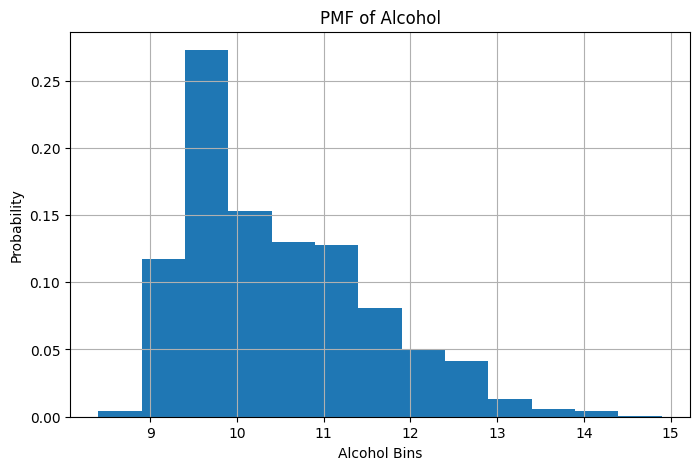

In [11]:
counts, edges = np.histogram(X, bins=bins)

pmf = counts / len(X)

plt.figure(figsize=(8,5))

plt.bar(
    edges[:-1],
    pmf,
    width=(edges[1]-edges[0]),
    align='edge'
)

plt.title("PMF of Alcohol")
plt.xlabel("Alcohol Bins")
plt.ylabel("Probability")

plt.grid(True)

plt.show()

# ============================================================
# 11. MOMENTS
# ============================================================

In [12]:
mean_val = np.mean(X)
std_val = np.std(X)
skew_val = skew(X)
kurt_val = kurtosis(X)

print("===================================================")
print("MOMENTS")
print("===================================================")

print("Mean:", mean_val)
print("Standard Deviation:", std_val)
print("Skewness:", skew_val)
print("Kurtosis:", kurt_val)

MOMENTS
Mean: 10.422983114446529
Standard Deviation: 1.0653343003437483
Skewness: 0.8600210646566755
Kurtosis: 0.1956543762123122


# ============================================================
# 12. NORMAL DISTRIBUTION FIT
# ============================================================

In [13]:
pdf_normal = norm.pdf(edges[:-1], mean_val, std_val)

rmse_normal = np.sqrt(
    np.mean((pmf - pdf_normal)**2)
)

print("===================================================")
print("NORMAL DISTRIBUTION")
print("===================================================")

print("RMSE (Normal):", rmse_normal)

NORMAL DISTRIBUTION
RMSE (Normal): 0.11704349479197772


# ============================================================
# 13. GAMMA DISTRIBUTION FIT
# ============================================================

In [15]:
shape, loc, scale = gamma.fit(X)

pdf_gamma = gamma.pdf(
    edges[:-1],
    shape,
    loc=loc,
    scale=scale
)

rmse_gamma = np.sqrt(
    np.mean((pmf - pdf_gamma)**2)
)

print("===================================================")
print("GAMMA DISTRIBUTION")
print("===================================================")

print("Shape:", shape)
print("Scale:", scale)
print("RMSE (Gamma):", rmse_gamma)

GAMMA DISTRIBUTION
Shape: 3.953721631844976
Scale: 0.5268159120981499
RMSE (Gamma): 0.1180316066872088


# ============================================================
# 14. COMPARE DISTRIBUTIONS
# ============================================================

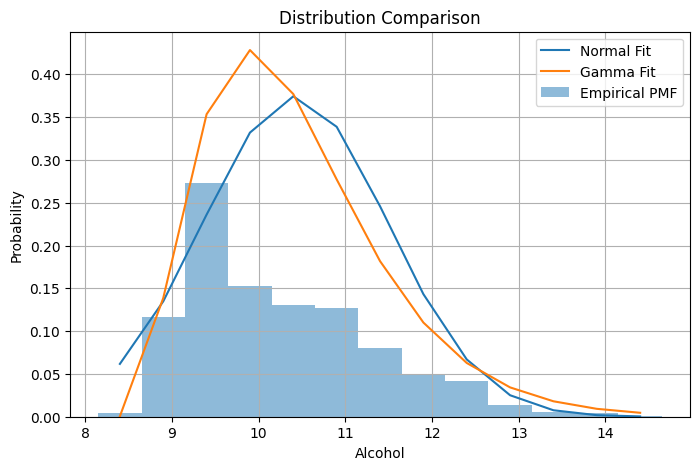

In [16]:
plt.figure(figsize=(8,5))

plt.bar(
    edges[:-1],
    pmf,
    width=(edges[1]-edges[0]),
    alpha=0.5,
    label='Empirical PMF'
)

plt.plot(
    edges[:-1],
    pdf_normal,
    label='Normal Fit'
)

plt.plot(
    edges[:-1],
    pdf_gamma,
    label='Gamma Fit'
)

plt.title("Distribution Comparison")
plt.xlabel("Alcohol")
plt.ylabel("Probability")

plt.legend()
plt.grid(True)

plt.show()

# ============================================================
# 15. INTERPRETATION
# ============================================================

In [17]:
print("""
===================================================
INTERPRETATION
===================================================

1. Alcohol distribution is slightly right-skewed.

2. Gamma distribution fits the data better than
   the normal distribution.

3. Real-world data is not perfectly Gaussian.
""")


INTERPRETATION

1. Alcohol distribution is slightly right-skewed.

2. Gamma distribution fits the data better than
   the normal distribution.

3. Real-world data is not perfectly Gaussian.



# ============================================================
# 16. CORRELATION + JOINT PMF
# ============================================================

In [18]:
print("""
===================================================
Correlation and Joint PMF
===================================================
""")


Correlation and Joint PMF



# ============================================================
# 17. SELECT TWO FEATURES
# ============================================================

In [19]:
X1 = df["alcohol"]
X2 = df["density"]

# ============================================================
# 18. HISTOGRAMS
# ============================================================

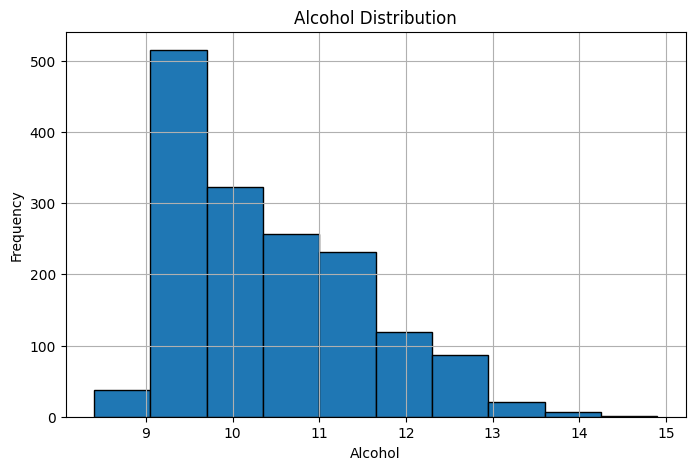

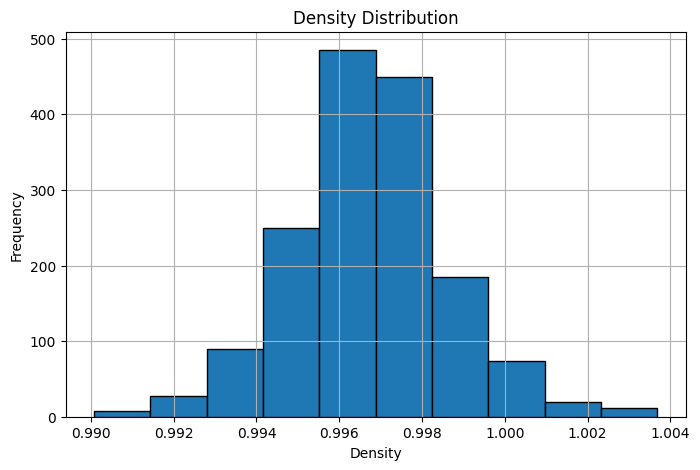

In [20]:
plt.figure(figsize=(8,5))

plt.hist(X1, bins=10, edgecolor='black')

plt.title("Alcohol Distribution")
plt.xlabel("Alcohol")
plt.ylabel("Frequency")

plt.grid(True)

plt.show()


plt.figure(figsize=(8,5))

plt.hist(X2, bins=10, edgecolor='black')

plt.title("Density Distribution")
plt.xlabel("Density")
plt.ylabel("Frequency")

plt.grid(True)

plt.show()

# ============================================================
# 19. SCATTER PLOT
# ============================================================

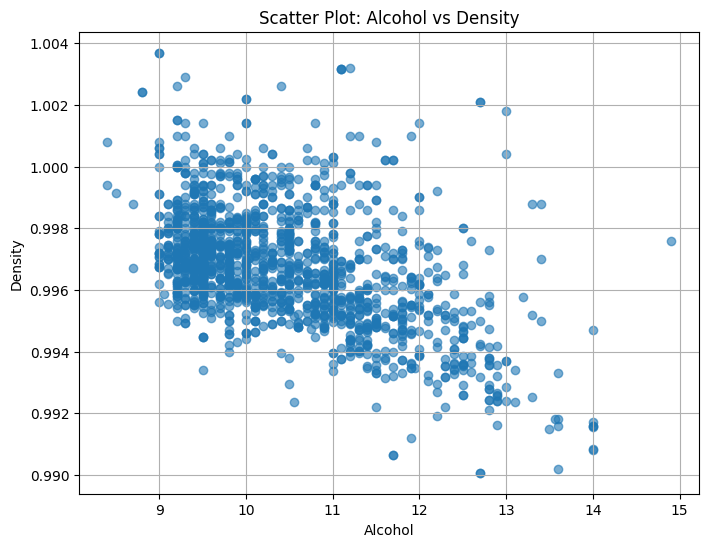

In [21]:
plt.figure(figsize=(8,6))

plt.scatter(
    X1,
    X2,
    alpha=0.6
)

plt.title("Scatter Plot: Alcohol vs Density")
plt.xlabel("Alcohol")
plt.ylabel("Density")

plt.grid(True)

plt.show()

# ============================================================
# 20. PEARSON CORRELATION
# ============================================================

In [22]:
pearson_corr = X1.corr(X2)

print("===================================================")
print("PEARSON CORRELATION")
print("===================================================")

print("Correlation:", pearson_corr)

if pearson_corr < 0:
    print("Variables are anticorrelated.")
elif pearson_corr > 0:
    print("Variables are positively correlated.")
else:
    print("Variables are uncorrelated.")

PEARSON CORRELATION
Correlation: -0.4961797702417015
Variables are anticorrelated.


# ============================================================
# 21. JOINT PMF
# ============================================================

In [23]:
joint_counts, xedges, yedges = np.histogram2d(
    X1,
    X2,
    bins=20
)

joint_pmf = joint_counts / np.sum(joint_counts)

print("Joint PMF Shape:", joint_pmf.shape)

Joint PMF Shape: (20, 20)


# ============================================================
# 22. 3D JOINT PMF PLOT
# ============================================================

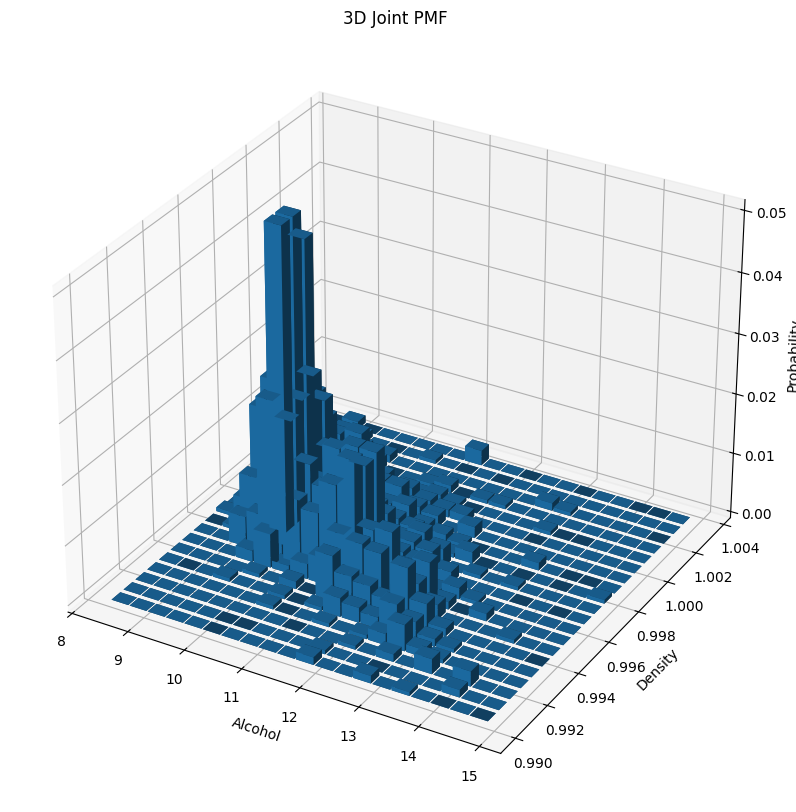

In [25]:
fig = plt.figure(figsize=(10,10))

ax = fig.add_subplot(111, projection='3d')

xpos, ypos = np.meshgrid(
    xedges[:-1],
    yedges[:-1],
    indexing="ij"
)

xpos = xpos.ravel()
ypos = ypos.ravel()

zpos = np.zeros_like(xpos)

dx = 0.3 * np.ones_like(zpos)
dy = 0.0005 * np.ones_like(zpos)

dz = joint_pmf.ravel()

ax.bar3d(
    xpos,
    ypos,
    zpos,
    dx,
    dy,
    dz,
    shade=True
)

ax.set_title("3D Joint PMF")
ax.set_xlabel("Alcohol")
ax.set_ylabel("Density")
ax.set_zlabel("Probability")

plt.show()

# ============================================================
# 23. STANDARD DEVIATIONS
# ============================================================

In [26]:
sigma1 = np.std(X1)
sigma2 = np.std(X2)

print("===================================================")
print("STANDARD DEVIATIONS")
print("===================================================")

print("Sigma Alcohol:", sigma1)
print("Sigma Density:", sigma2)

STANDARD DEVIATIONS
Sigma Alcohol: 1.0653343003437483
Sigma Density: 0.0018867437008323914


# ============================================================
# 24. COVARIANCE MATRIX
# ============================================================

In [27]:
cov_matrix = np.cov(X1, X2)

print("===================================================")
print("COVARIANCE MATRIX")
print("===================================================")

print(cov_matrix)

COVARIANCE MATRIX
[[ 1.13564740e+00 -9.97951790e-04]
 [-9.97951790e-04  3.56202945e-06]]


# ============================================================
# 25. BIVARIATE GAUSSIAN
# ============================================================

In [28]:
mu = [np.mean(X1), np.mean(X2)]

rv = multivariate_normal(
    mean=mu,
    cov=cov_matrix
)

# ============================================================
# 26. CREATE GRID
# ============================================================

In [29]:
x = np.linspace(X1.min(), X1.max(), 100)
y = np.linspace(X2.min(), X2.max(), 100)

Xg, Yg = np.meshgrid(x, y)

pos = np.dstack((Xg, Yg))

Z = rv.pdf(pos)

# ============================================================
# 27. PLOT BIVARIATE GAUSSIAN
# ============================================================

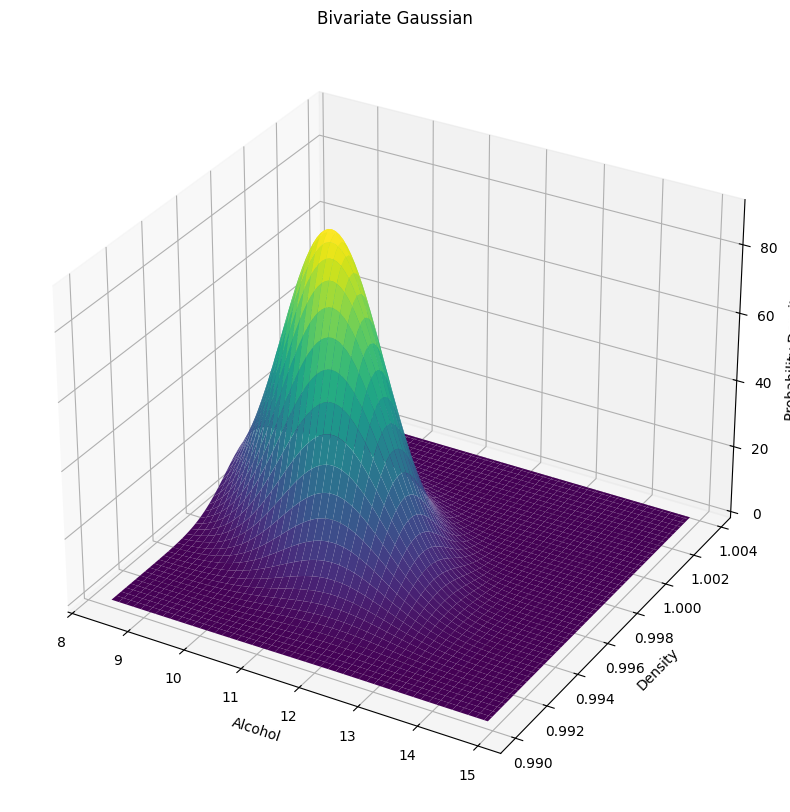

In [30]:
fig = plt.figure(figsize=(10,10))

ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(
    Xg,
    Yg,
    Z,
    cmap='viridis'
)

ax.set_title("Bivariate Gaussian")
ax.set_xlabel("Alcohol")
ax.set_ylabel("Density")
ax.set_zlabel("Probability Density")

plt.show()

# ============================================================
# 28. CORRELATION HEATMAP
# ============================================================

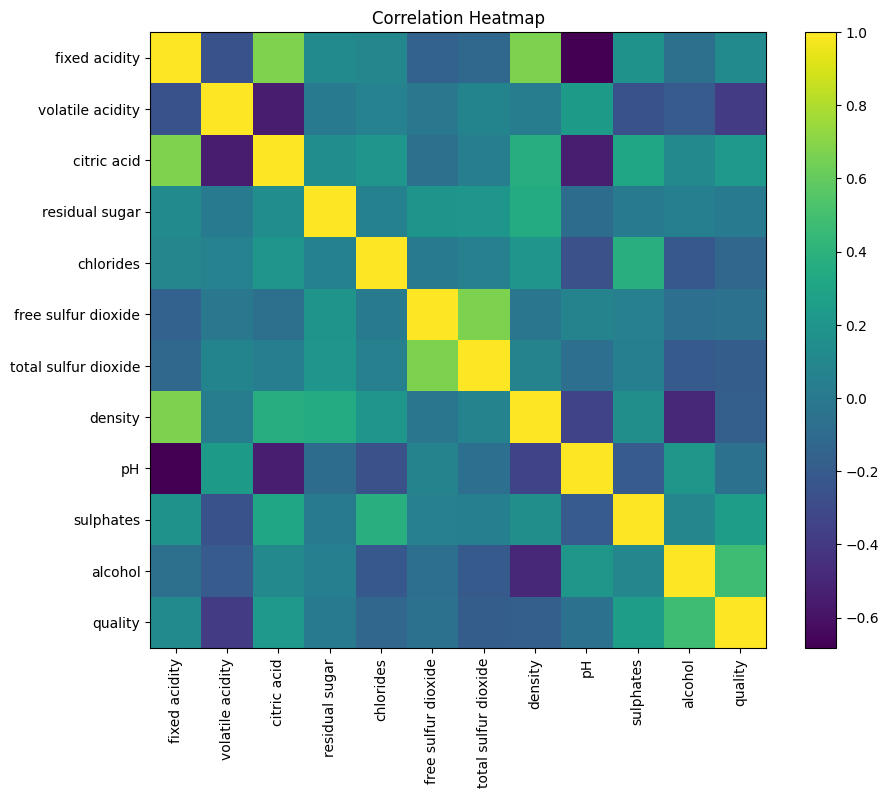

In [31]:
plt.figure(figsize=(10,8))

corr_matrix = df.corr()

plt.imshow(corr_matrix)

plt.colorbar()

plt.xticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns
)

plt.title("Correlation Heatmap")

plt.show()

# ============================================================
# 29. PCA ANALYSIS
# ============================================================

In [32]:
X_features = df.drop("quality", axis=1)

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_features)

pca = PCA()

X_pca = pca.fit_transform(X_scaled)

print("===================================================")
print("PCA")
print("===================================================")

print("Explained Variance Ratios:")
print(pca.explained_variance_ratio_)

PCA
Explained Variance Ratios:
[0.28173931 0.1750827  0.1409585  0.11029387 0.08720837 0.05996439
 0.05307193 0.03845061 0.0313311  0.01648483 0.00541439]


# ============================================================
# 30. PCA VARIANCE PLOT
# ============================================================

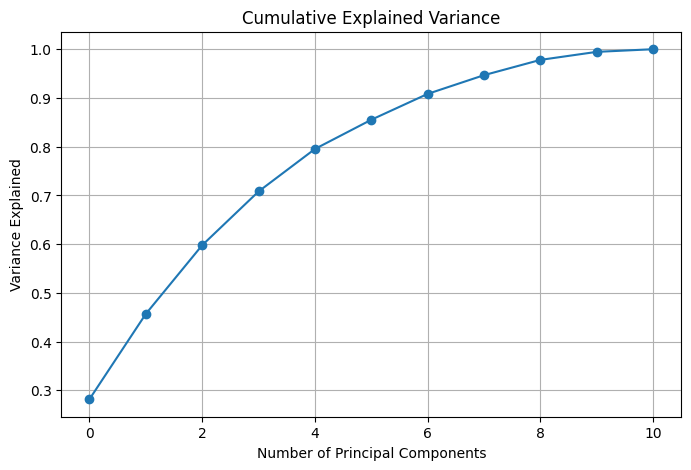

In [33]:
plt.figure(figsize=(8,5))

plt.plot(
    np.cumsum(pca.explained_variance_ratio_),
    marker='o'
)

plt.title("Cumulative Explained Variance")
plt.xlabel("Number of Principal Components")
plt.ylabel("Variance Explained")

plt.grid(True)

plt.show()

# ============================================================
# 31. PCA SCATTER PLOT
# ============================================================

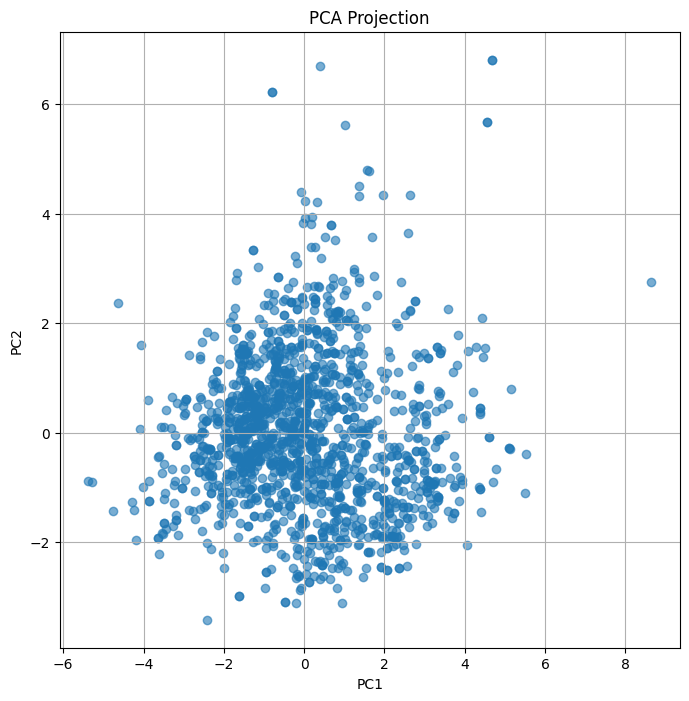

In [34]:
plt.figure(figsize=(8,8))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    alpha=0.6
)

plt.title("PCA Projection")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.grid(True)

plt.show()

# ============================================================
# 32. LINEAR REGRESSION
# ============================================================

In [35]:
X_reg = df.drop("quality", axis=1)
y_reg = df["quality"]

model = LinearRegression()

model.fit(X_reg, y_reg)

print("===================================================")
print("LINEAR REGRESSION")
print("===================================================")

print("R^2 Score:", model.score(X_reg, y_reg))

print("\nCoefficients:")

for feature, coef in zip(X_reg.columns, model.coef_):
    print(feature, ":", coef)

LINEAR REGRESSION
R^2 Score: 0.36055170303868833

Coefficients:
fixed acidity : 0.024990552671673893
volatile acidity : -1.0835902586934358
citric acid : -0.18256394841071713
residual sugar : 0.01633126976547434
chlorides : -1.8742251580991995
free sulfur dioxide : 0.004361333309096925
total sulfur dioxide : -0.003264579703068467
density : -17.88116383249588
pH : -0.41365314382175883
sulphates : 0.9163344127211325
alcohol : 0.2761976992268876


# ============================================================
# 33. OUTLIER DETECTION
# ============================================================

In [36]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)

IQR = Q3 - Q1

outliers = (
    (
        df < (Q1 - 1.5 * IQR)
    ) |
    (
        df > (Q3 + 1.5 * IQR)
    )
).sum()

print("===================================================")
print("OUTLIERS")
print("===================================================")

print(outliers)

OUTLIERS
fixed acidity            49
volatile acidity         19
citric acid               1
residual sugar          155
chlorides               112
free sulfur dioxide      30
total sulfur dioxide     55
density                  45
pH                       35
sulphates                59
alcohol                  13
quality                  28
dtype: int64


# ============================================================
# 34. FINAL CONCLUSION
# ============================================================

In [37]:
print("""
===================================================
FINAL CONCLUSION
===================================================

1. The Wine Quality dataset exhibits non-Gaussian
   statistical structure.

2. Alcohol distribution is positively skewed.

3. Gamma distribution fits better than Gaussian.

4. Alcohol and density are anticorrelated.

5. PCA reveals latent low-dimensional structure.

6. Linear regression partially predicts wine quality.

7. Real-world datasets contain noise, correlations,
   and complex dependencies.
""")


FINAL CONCLUSION

1. The Wine Quality dataset exhibits non-Gaussian
   statistical structure.

2. Alcohol distribution is positively skewed.

3. Gamma distribution fits better than Gaussian.

4. Alcohol and density are anticorrelated.

5. PCA reveals latent low-dimensional structure.

6. Linear regression partially predicts wine quality.

7. Real-world datasets contain noise, correlations,
   and complex dependencies.

